✅ Random Forest Results
Accuracy: 0.7699553792761527
ROC-AUC: 0.7979943673690577

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.78      0.86      7482
           1       0.19      0.67      0.30       586

    accuracy                           0.77      8068
   macro avg       0.58      0.72      0.58      8068
weighted avg       0.91      0.77      0.82      8068



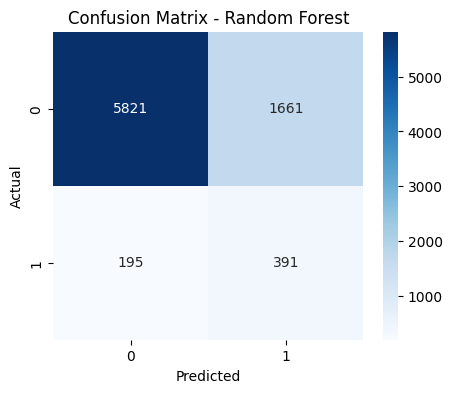

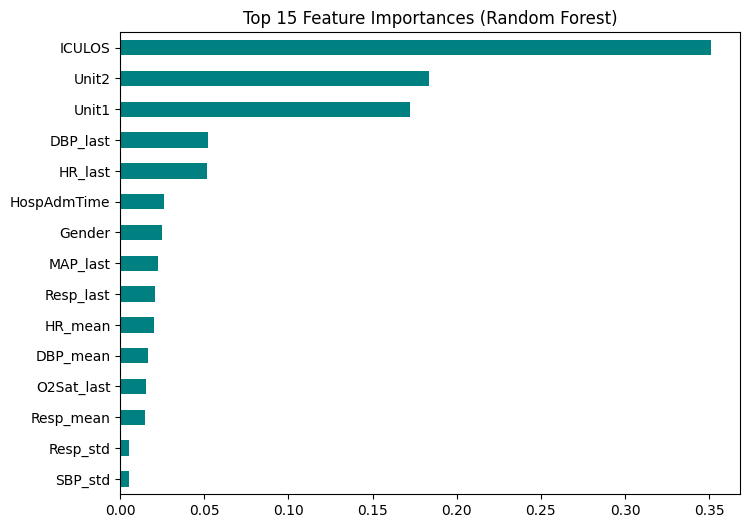

In [4]:
##########         RANDOM FOREST CLASSIFIER
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Read saved data ---
train_data = pd.read_csv("../../data/raw/processed_data/train_resampled.csv")
test_data  = pd.read_csv("../../data/raw/processed_data/test_data.csv")

# --- 2️⃣ Split features and target ---
X_train = train_data.drop(columns=['SepsisLabel'])
y_train = train_data['SepsisLabel']

X_test = test_data.drop(columns=['SepsisLabel'])
y_test = test_data['SepsisLabel']

# --- 3️⃣ Scale the features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4️⃣ Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=4,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

rf.fit(X_train_scaled, y_train)

# --- 5️⃣ Predict and evaluate ---
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]  # probabilities for class 1

print("✅ Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 6️⃣ Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# --- 7️⃣ Feature importance ---
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances[:15].plot(kind='barh', color='teal')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Read saved data ---
train_data = pd.read_csv("../../data/raw/processed_data/train_resampled.csv")
test_data  = pd.read_csv("../../data/raw/processed_data/test_data.csv")

# --- 2️⃣ Split features and target ---
X_train = train_data.drop(columns=['SepsisLabel'])
y_train = train_data['SepsisLabel']

X_test = test_data.drop(columns=['SepsisLabel'])
y_test = test_data['SepsisLabel']

# --- 3️⃣ Scale the features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print("Train accuracy:", rf.score(X_train_scaled, y_train))
print("Test accuracy:", rf.score(X_test_scaled, y_test))


Train accuracy: 0.8804057215426776
Test accuracy: 0.7524789291026277


✅ Decision Tree Results
Accuracy: 0.8632870599900843
ROC-AUC: 0.8415247789233409

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92      7482
           1       0.31      0.71      0.43       586

    accuracy                           0.86      8068
   macro avg       0.64      0.79      0.68      8068
weighted avg       0.93      0.86      0.89      8068



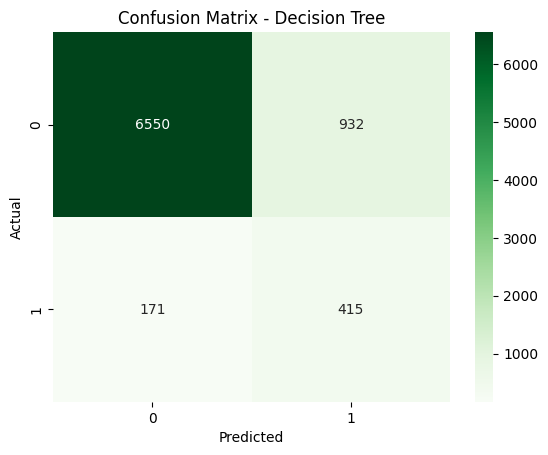

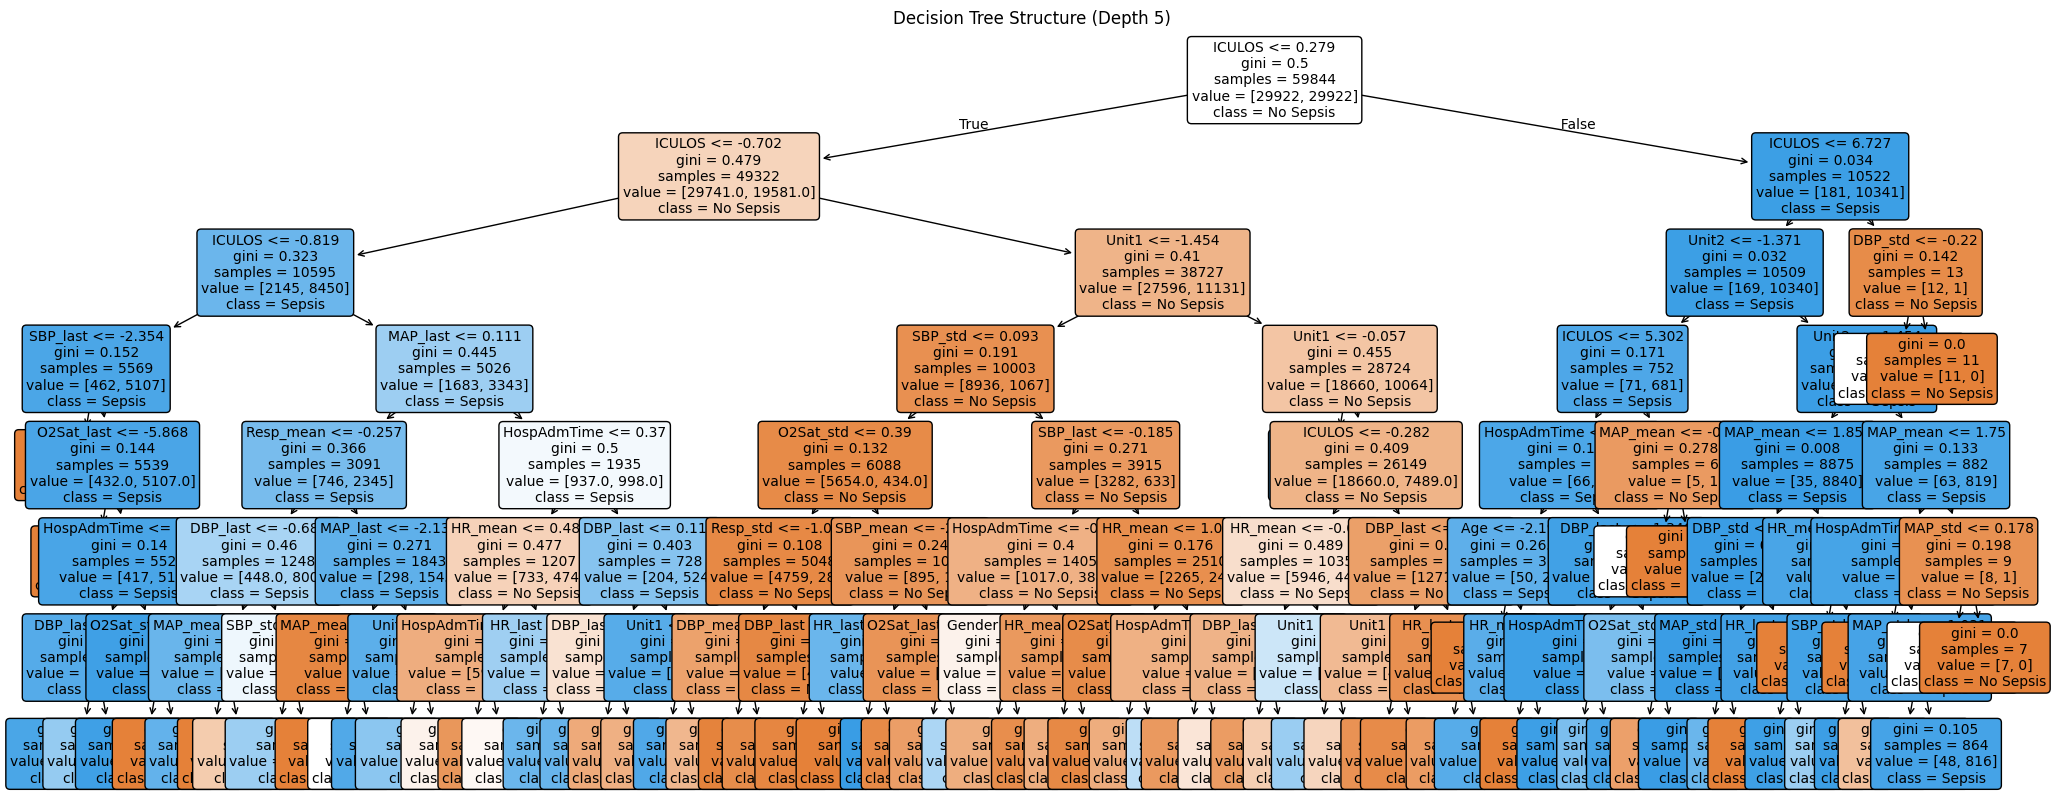

In [ ]:
########  DECISION TREE
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1️⃣ Initialize Decision Tree ---
dt = DecisionTreeClassifier(
    max_depth=7,          # limit depth so it's easier to visualize
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# --- 2️⃣ Train ---
dt.fit(X_train_scaled, y_train)

# --- 3️⃣ Predict ---
y_pred_dt = dt.predict(X_test_scaled)
y_proba = dt.predict_proba(X_test_scaled)[:, 1]  # probabilities for class 1

# --- 4️⃣ Evaluate ---
print("✅ Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# --- 5️⃣ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# --- 6️⃣ Visualize the Tree ---
plt.figure(figsize=(25, 10))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=['No Sepsis', 'Sepsis'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure (Depth 5)")
plt.show()


In [29]:
print("Train Accuracy:", dt.score(X_train_scaled, y_train))
print("Test Accuracy:", dt.score(X_test_scaled, y_test))


Train Accuracy: 0.8507954013769133
Test Accuracy: 0.8632870599900843


✅ Random Forest + ExtraTrees (Jugadd Ensemble) Results
Accuracy: 0.7834655428854734
ROC-AUC: 0.810307878840959

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.79      0.87      7482
           1       0.20      0.64      0.30       586

    accuracy                           0.78      8068
   macro avg       0.58      0.72      0.59      8068
weighted avg       0.91      0.78      0.83      8068



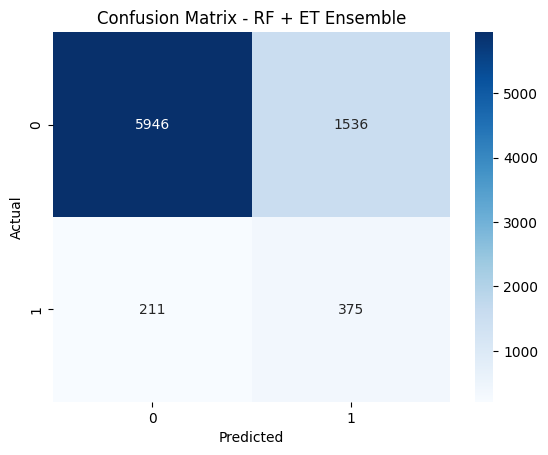

In [ ]:
########## RF + ET ENSEMBLE
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Individual models ---
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

et = ExtraTreesClassifier(  # very similar to RF but more random
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    bootstrap=False,
    n_jobs=-1,
    random_state=42
)

# --- 2️⃣ Combine both ("Jugadd Forest of Forests") ---
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('et', et)],
    voting='soft',   # average probabilities
    n_jobs=-1
)

# --- 3️⃣ Train ---
ensemble.fit(X_train_scaled, y_train)

# --- 4️⃣ Predict ---
y_pred = ensemble.predict(X_test_scaled)
y_proba = ensemble.predict_proba(X_test_scaled)[:, 1]  # probabilities for class 1

# --- 5️⃣ Evaluate ---
print("✅ Random Forest + ExtraTrees (Jugadd Ensemble) Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 6️⃣ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RF + ET Ensemble")
plt.show()


In [25]:
print("Train Accuracy:", ensemble.score(X_train_scaled, y_train))
print("Test Accuracy:", ensemble.score(X_test_scaled, y_test))


Train Accuracy: 0.9994986966111891
Test Accuracy: 0.7834655428854734


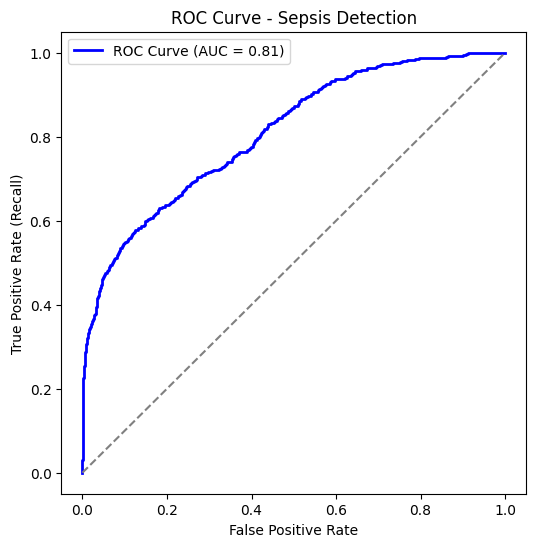

In [ ]:
####### PLOT ROC OF RF + ET
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_proba = ensemble.predict_proba(X_test_scaled)[:, 1]  # probs for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Sepsis Detection')
plt.legend()
plt.show()


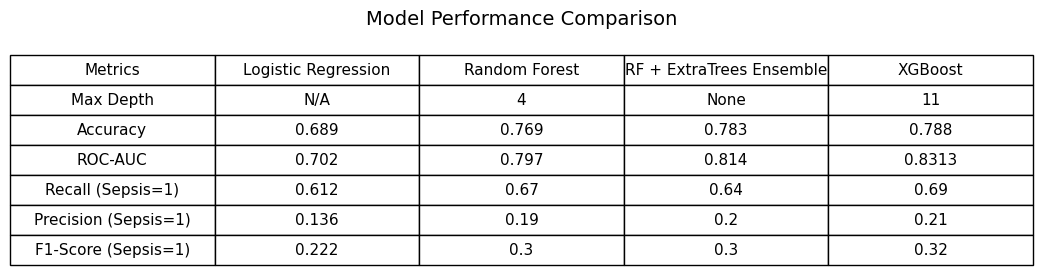

In [ ]:
#######     COMPARE MULTIPLE MODELS AND PLOT IMAGE
import pandas as pd
import matplotlib.pyplot as plt

# --- Data (organized by metrics) ---
results = {
    "Metrics": ["Max Depth", "Accuracy", "ROC-AUC", "Recall (Sepsis=1)", 
                "Precision (Sepsis=1)", "F1-Score (Sepsis=1)"],
    "Logistic Regression": ["N/A", 0.689, 0.702, 0.612, 0.136, 0.222],
    # "Random Forest": ["4", 0.769, 0.797, 0.67, 0.19, 0.30],
    "RF + ExtraTrees Ensemble": ["None", 0.783, 0.814, 0.640, 0.200, 0.300],
    "XGBoost":["11", 0.811, 0.8313, 0.69, 0.21, 0.32]
}

results_df = pd.DataFrame(results)

# --- Plot table as image ---
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis('off')

table = ax.table(cellText=results_df.values,
                 colLabels=results_df.columns,
                 cellLoc='center',
                 loc='center')

# Beautify
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title("Model Performance Comparison", fontsize=14, pad=20)
plt.savefig("../../results/model_comparison_metrics_based.png", bbox_inches='tight', dpi=300)
plt.show()


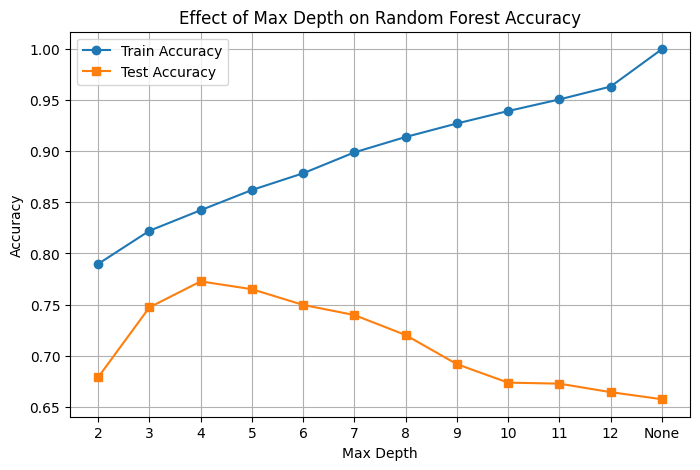

In [8]:
######## RF performance by varying max_depth param AND PLOT IT
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- Try different depths ---
depths = [2,3, 4, 5, 6, 7, 8, 9, 10, 11, 12, None]
train_acc = []
test_acc = []

for d in depths:
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=d,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_scaled, y_train)
    
    train_pred = rf.predict(X_train_scaled)
    test_pred = rf.predict(X_test_scaled)
    
    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(depths[:-1] + ['None'], train_acc, marker='o', label='Train Accuracy')
plt.plot(depths[:-1] + ['None'], test_acc, marker='s', label='Test Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Max Depth on Random Forest Accuracy")
plt.legend()
plt.grid(True)
plt.show()
